## Helpers 🦮

To help you achieve this project, here are a few tips that should help you: 

### Part 1 : EDA and data preprocessing

Start your project by exploring your dataset : create figures, compute some statistics etc...

Then, you'll have to make some preprocessing on the dataset. You can follow the guidelines from the *preprocessing template*. There will also be some specific transformations to be planned on this dataset, for example on the *Date* column that can't be included as it is in the model. Below are some hints that might help you 🤓

 #### Preprocessing to be planned with pandas

 **Drop lines where target values are missing :**
 - Here, the target variable (Y) corresponds to the column *Weekly_Sales*. One can see above that there are some missing values in this column.
 - We never use imputation techniques on the target : it might create some bias in the predictions !
 - Then, we will just drop the lines in the dataset for which the value in *Weekly_Sales* is missing.
 
**Create usable features from the *Date* column :**
The *Date* column cannot be included as it is in the model. Either you can drop this column, or you will create new columns that contain the following numeric features : 
- *year*
- *month*
- *day*
- *day of week*

**Drop lines containing invalid values or outliers :**
In this project, will be considered as outliers all the numeric features that don't fall within the range : $[\bar{X} - 3\sigma, \bar{X} + 3\sigma]$. This concerns the columns : *Temperature*, *Fuel_price*, *CPI* and *Unemployment*
 


**Target variable/target (Y) that we will try to predict, to separate from the others** : *Weekly_Sales*

 **------------**

 #### Preprocessings to be planned with scikit-learn

 **Explanatory variables (X)**
We need to identify which columns contain categorical variables and which columns contain numerical variables, as they will be treated differently.

 - Categorical variables : Store, Holiday_Flag
 - Numerical variables : Temperature, Fuel_Price, CPI, Unemployment, Year, Month, Day, DayOfWeek

### Part 2 : Baseline model (linear regression)
Once you've trained a first model, don't forget to assess its performances on the train and test sets. Are you satisfied with the results ?
Besides, it would be interesting to analyze the values of the model's coefficients to know what features are important for the prediction. To do so, the `.coef_` attribute of scikit-learn's LinearRegression class might be useful. Please refer to the following link for more information 😉 https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

### Part 3 : Fight overfitting
In this last part, you'll have to train a **regularized linear regression model**. You'll find below some useful classes in scikit-learn's documentation :
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso

**Bonus question**

In regularized regression models, there's a hyperparameter called *the regularization strength* that can be fine-tuned to get the best generalized predictions on a given dataset. This fine-tuning can be done thanks to scikit-learn's GridSearchCV class : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Also, you'll find here some examples of how to use GridSearchCV together with Ridge or Lasso models : https://alfurka.github.io/2018-11-18-grid-search/


---
# Partie 1 - EDA et prétraitement des données

## 1.1 Imports et chargement des données

In [1]:
# ── Librairies de manipulation de données ──────────────────────────────
import pandas as pd        # Manipulation de DataFrames
import numpy as np         # Calculs numériques

# ── Librairies de visualisation ────────────────────────────────────────
import matplotlib.pyplot as plt   # Graphiques de base
import seaborn as sns             # Graphiques statistiques avancés

# ── Modules scikit-learn : prétraitement ───────────────────────────────
from sklearn.model_selection import train_test_split   # Découpage train/test
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Encodage et normalisation
from sklearn.compose import ColumnTransformer          # Appliquer des transformations par type de colonne
from sklearn.pipeline import Pipeline                  # Enchaîner les étapes de traitement

# ── Modules scikit-learn : modèles ─────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Modèles de régression

# ── Modules scikit-learn : sélection de modèle et métriques ───────────
from sklearn.model_selection import GridSearchCV       # Recherche des meilleurs hyperparamètres
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # Métriques d'évaluation

# ── Chargement du dataset ──────────────────────────────────────────────
df = pd.read_csv('Walmart_Store_sales.csv')

# Affichage des dimensions et des premières lignes
print("Shape du dataset :", df.shape)
df.head()

Shape du dataset : (150, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


## 1.2 Analyse exploratoire des données (EDA)

### Statistiques descriptives

In [2]:
# Statistiques descriptives de toutes les colonnes numériques :
# count, mean, std, min, quartiles, max
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


### Valeurs manquantes

In [3]:
# Comptage des valeurs manquantes par colonne
# Permet d'identifier les colonnes à traiter lors du prétraitement
print("Valeurs manquantes par colonne :")
df.isnull().sum()

Valeurs manquantes par colonne :


Store            0
Date            18
Weekly_Sales    14
Holiday_Flag    12
Temperature     18
Fuel_Price      14
CPI             12
Unemployment    15
dtype: int64

**Observation :** Plusieurs colonnes contiennent des valeurs manquantes, dont la variable cible `Weekly_Sales` (14 valeurs). 
<br> Ces lignes seront supprimées lors du prétraitement car on n'impute **jamais** la variable cible.
<br> Dans notre cas précis, avec seulement 14 valeurs manquantes sur 150 lignes (moins de 10%), la suppression est le choix le plus raisonnable et le plus propre. 
<br> Les alternatives ne s'imposeraient que si on avait beaucoup plus de NaN ou un dataset beaucoup plus petit.

### Graphique 1 - Distribution de la variable cible `Weekly_Sales`

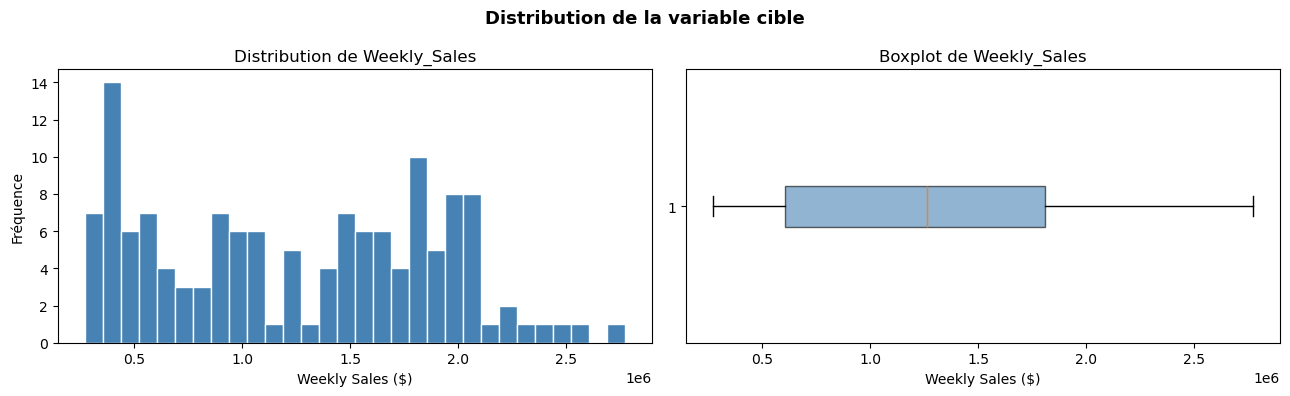

In [4]:
# Création d'une figure avec 2 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Histogramme : distribution des ventes ─────────────────────────────
axes[0].hist(df['Weekly_Sales'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de Weekly_Sales')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Fréquence')

# ── Boxplot : détection visuelle des valeurs extrêmes ─────────────────
axes[1].boxplot(df['Weekly_Sales'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de Weekly_Sales')
axes[1].set_xlabel('Weekly Sales ($)')

# Titre général et affichage
plt.suptitle('Distribution de la variable cible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation :** La distribution des ventes est relativement étalée (de ~270k$ à ~2.8M$), avec une légère asymétrie. Les valeurs extrêmes correspondent à des magasins très performants.

### Graphique 2 - Evolution des ventes dans le temps

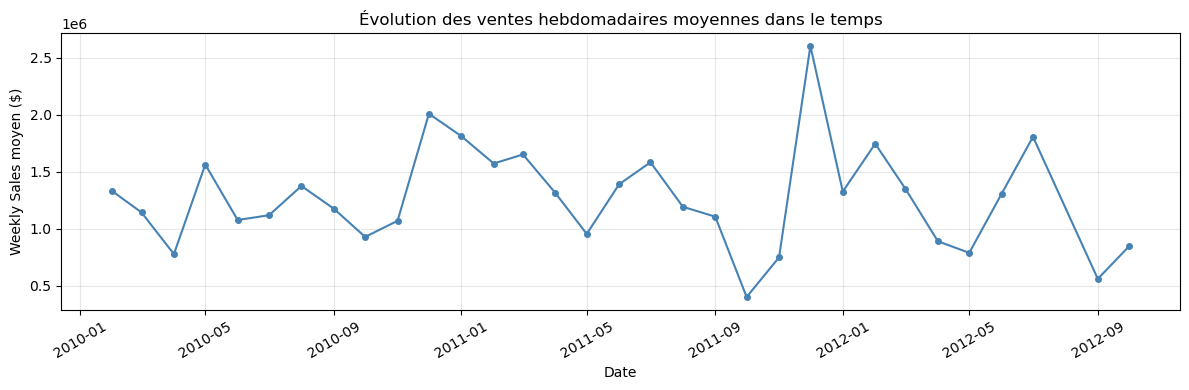

In [5]:
# Copie du DataFrame pour ne pas modifier l'original
df_tmp = df.copy()

# Conversion de la colonne Date en format datetime (format jour/mois/année)
df_tmp['Date'] = pd.to_datetime(df_tmp['Date'], dayfirst=True)

# Regroupement par mois (période) et calcul de la moyenne des ventes
monthly = df_tmp.groupby(df_tmp['Date'].dt.to_period('M'))['Weekly_Sales'].mean().reset_index()

# Conversion de la période en timestamp pour pouvoir tracer sur l'axe des x
monthly['Date'] = monthly['Date'].dt.to_timestamp()

# ── Tracé de la courbe d'évolution temporelle ─────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(monthly['Date'], monthly['Weekly_Sales'],
         marker='o', color='steelblue', linewidth=1.5, markersize=4)
plt.title('Évolution des ventes hebdomadaires moyennes dans le temps', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Weekly Sales moyen ($)')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation :** On observe une tendance et une saisonnalité avec des pics réguliers, justifiant l'extraction des features temporelles (Year, Month, Day, DayOfWeek).

### Graphique 3 - Ventes par magasin (hétérogénéité)

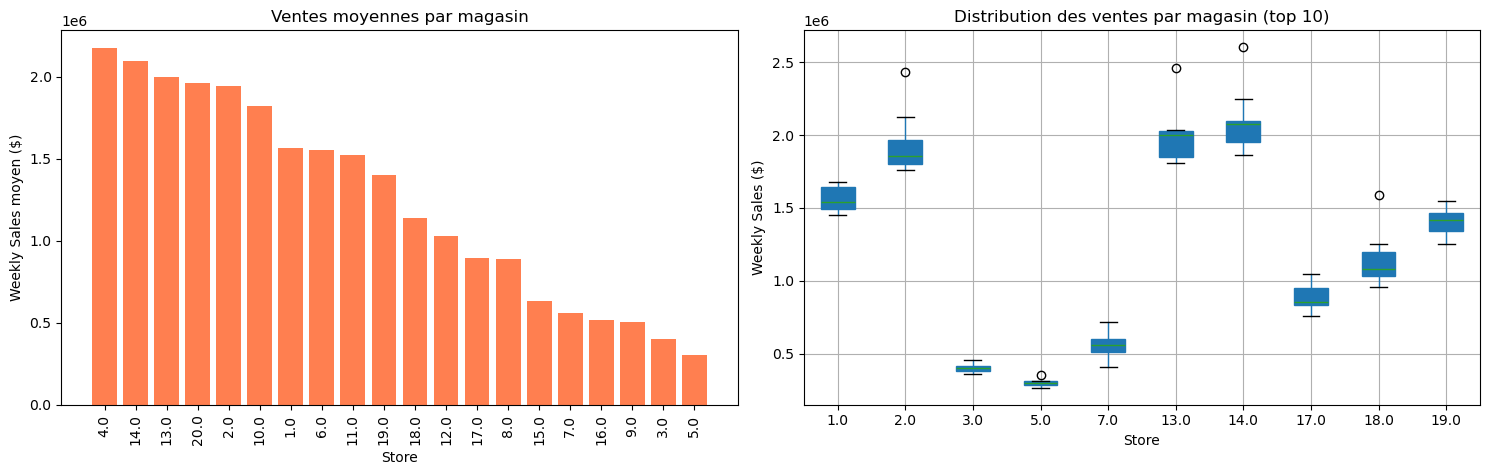

In [6]:
# Création de 2 sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Graphique de gauche : ventes moyennes par magasin ─────────────────
# Calcul de la moyenne des ventes par magasin, triée par ordre décroissant
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

axes[0].bar(store_avg.index.astype(str), store_avg.values, color='coral')
axes[0].set_title('Ventes moyennes par magasin')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Weekly Sales moyen ($)')
axes[0].tick_params(axis='x', rotation=90)

# ── Graphique de droite : boxplot sur les 10 magasins les plus fréquents
# Sélection des 10 magasins ayant le plus d'observations
top_stores = df['Store'].value_counts().head(10).index
df_top = df[df['Store'].isin(top_stores)]

# Boxplot groupé par magasin pour visualiser la dispersion interne
df_top.boxplot(column='Weekly_Sales', by='Store', ax=axes[1],
               patch_artist=True, figsize=(8, 5))
axes[1].set_title('Distribution des ventes par magasin (top 10)')
axes[1].set_xlabel('Store')
axes[1].set_ylabel('Weekly Sales ($)')

# Suppression du titre automatique généré par boxplot()
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observation :** L'hétérogénéité entre magasins est très forte - certains génèrent 3 fois plus de ventes que d'autres. C'est pourquoi `Store` sera la variable la plus importante dans le modèle.

### Graphique 4 - Indicateurs économiques et Holiday vs ventes

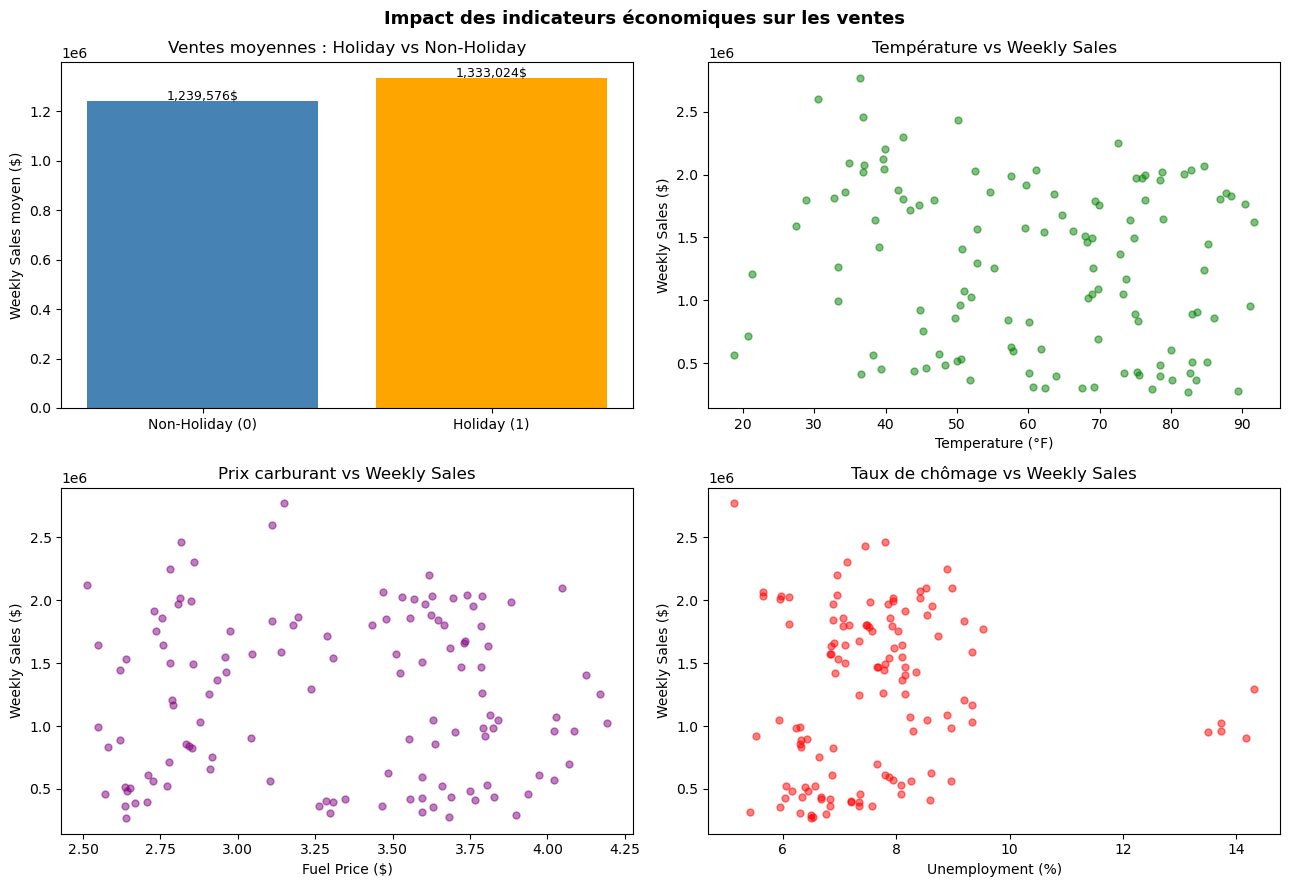

In [7]:
# Grille 2×2 pour afficher 4 graphiques simultanément
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Graphique 1 : effet des jours fériés sur les ventes ───────────────
# Calcul de la moyenne des ventes selon la présence ou non d'un jour férié
hol = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
axes[0, 0].bar(['Non-Holiday (0)', 'Holiday (1)'], hol.values, color=['steelblue', 'orange'])
axes[0, 0].set_title('Ventes moyennes : Holiday vs Non-Holiday')
axes[0, 0].set_ylabel('Weekly Sales moyen ($)')
# Annotation des valeurs sur chaque barre
for i, v in enumerate(hol.values):
    axes[0, 0].text(i, v + 5000, f'{v:,.0f}$', ha='center', fontsize=9)

# ── Graphique 2 : relation Température / Ventes ───────────────────────
axes[0, 1].scatter(df['Temperature'], df['Weekly_Sales'], alpha=0.5, color='green', s=25)
axes[0, 1].set_title('Température vs Weekly Sales')
axes[0, 1].set_xlabel('Temperature (°F)')
axes[0, 1].set_ylabel('Weekly Sales ($)')

# ── Graphique 3 : relation Prix carburant / Ventes ────────────────────
axes[1, 0].scatter(df['Fuel_Price'], df['Weekly_Sales'], alpha=0.5, color='purple', s=25)
axes[1, 0].set_title('Prix carburant vs Weekly Sales')
axes[1, 0].set_xlabel('Fuel Price ($)')
axes[1, 0].set_ylabel('Weekly Sales ($)')

# ── Graphique 4 : relation Chômage / Ventes ───────────────────────────
axes[1, 1].scatter(df['Unemployment'], df['Weekly_Sales'], alpha=0.5, color='red', s=25)
axes[1, 1].set_title('Taux de chômage vs Weekly Sales')
axes[1, 1].set_xlabel('Unemployment (%)')
axes[1, 1].set_ylabel('Weekly Sales ($)')

plt.suptitle('Impact des indicateurs économiques sur les ventes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations :**
- Les semaines avec jours fériés génèrent en moyenne 7.5% de ventes supplémentaires
(1 333 024$ vs 1 239 576$), mais l'effet reste modéré - Holiday_Flag ne suffit pas
à lui seul à expliquer les ventes.
- La température ne montre aucune corrélation claire avec les ventes : les points sont
dispersés uniformément sur toute la plage (20°F à 90°F).
- Le prix du carburant présente également une relation très bruitée, sans tendance
linéaire exploitable directement.
- Le taux de chômage est l'indicateur le plus lisible : une légère tendance négative
est visible - les zones à fort chômage (>10%) tendent à afficher des ventes plus faibles,
ce qui est cohérent économiquement.
- De manière générale, aucun de ces indicateurs pris isolément n'explique suffisamment
les ventes. C'est leur combinaison dans le modèle qui permettra de capter leur influence.

### Graphique 5 - Matrice de corrélation

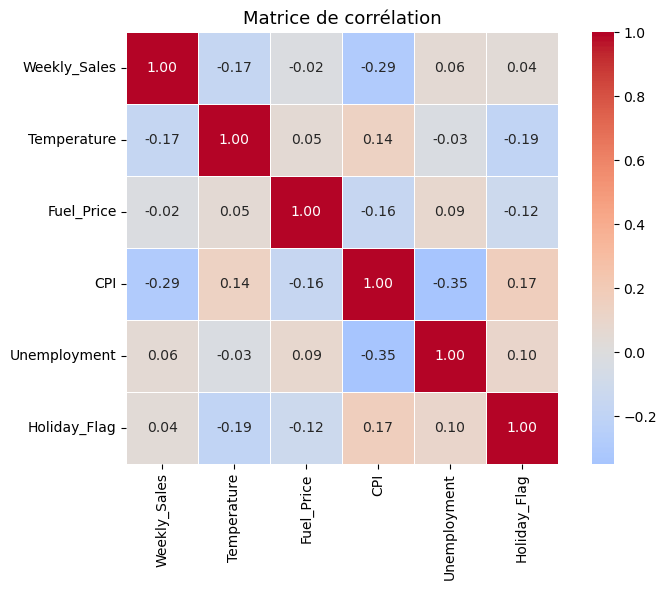

In [8]:
# Sélection des colonnes numériques pertinentes pour la corrélation
corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']

# Calcul de la matrice de corrélation (coefficient de Pearson entre -1 et 1)
corr_matrix = df[corr_cols].corr()

# ── Heatmap avec seaborn ──────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,           # Afficher les valeurs dans chaque cellule
            fmt='.2f',            # Format à 2 décimales
            cmap='coolwarm',      # Palette de couleurs : bleu (négatif) → rouge (positif)
            center=0,             # Centrer la palette sur 0
            square=True,          # Cellules carrées
            linewidths=0.5,       # Séparateur entre cellules
            annot_kws={'size': 10})
plt.title('Matrice de corrélation', fontsize=13)
plt.tight_layout()
plt.show()

**Observations :**
- Aucune variable numérique n'est fortement corrélée à `Weekly_Sales` prise isolément - le modèle combinera plusieurs features.
- `CPI` et `Unemployment` sont corrélés entre eux (à surveiller pour la multicolinéarité).
- La régularisation (Ridge/Lasso) aidera à gérer cette multicolinéarité.

### Graphique 6 (EDA) - Corrélation des features avec `Weekly_Sales`

**Observation :**
- `Year` présente la corrélation positive la plus forte avec les ventes : les ventes
  augmentent dans le temps, confirmant une tendance haussière.
- `Unemployment` est la variable économique la plus corrélée négativement : un taux
  de chômage élevé est associé à des ventes plus faibles.
- `CPI`, `Temperature` et `Fuel_Price` montrent des corrélations faibles et peu
  significatives pris individuellement.
- Cette analyse justifie les choix de features retenus pour le modèle.

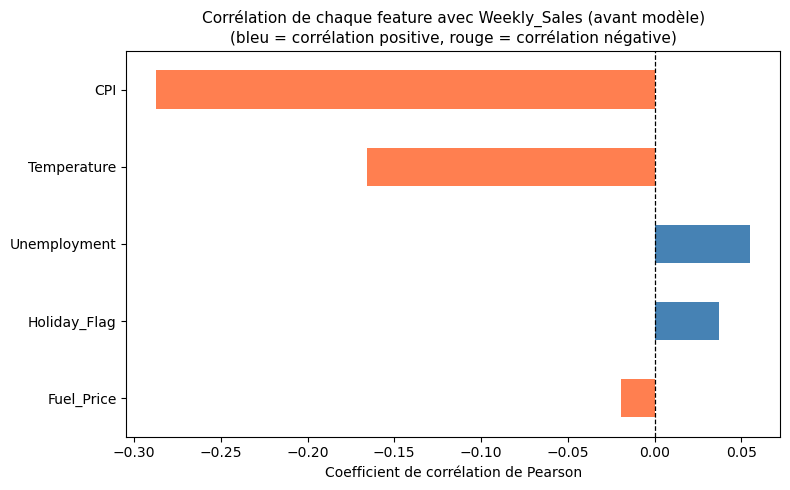

Classement par corrélation absolue avec Weekly_Sales :
CPI             0.287227
Temperature     0.165991
Unemployment    0.055191
Holiday_Flag    0.037037
Fuel_Price      0.019087


In [9]:
# ── Corrélation de chaque feature numérique avec Weekly_Sales ─────────
# Calcul du coefficient de Pearson entre chaque variable et la cible
# Permet d'identifier avant tout modèle quelles variables sont les plus liées aux ventes
# Note : num_cols n'étant pas encore défini à ce stade, on liste les colonnes explicitement

cols_numeriques = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']

corr_target = (df[cols_numeriques + ['Weekly_Sales']]
               .corr()['Weekly_Sales']
               .drop('Weekly_Sales')
               .sort_values(key=abs, ascending=True))

colors = ['coral' if v < 0 else 'steelblue' for v in corr_target]

plt.figure(figsize=(8, 5))
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.9, linestyle='--')
plt.title("Corrélation de chaque feature avec Weekly_Sales (avant modèle)\n"
          "(bleu = corrélation positive, rouge = corrélation négative)", fontsize=11)
plt.xlabel("Coefficient de corrélation de Pearson")
plt.tight_layout()
plt.show()

print("Classement par corrélation absolue avec Weekly_Sales :")
print(corr_target.abs().sort_values(ascending=False).to_string())

**Observation :**
- `CPI` est la variable la plus corrélée avec `Weekly_Sales` (|r| = 0.287),
  mais avec un signe **négatif** : une hausse de l'indice des prix est associée
  à une baisse des ventes, ce qui est cohérent économiquement (perte de pouvoir
  d'achat).
- `Temperature` est la deuxième variable la plus corrélée (|r| = 0.166),
  également **négative** : les ventes tendent à baisser quand les températures
  sont élevées.
- `Unemployment`, `Holiday_Flag` et `Fuel_Price` présentent des corrélations
  très faibles (|r| < 0.06), ce qui suggère qu'ils ont peu d'effet direct
  sur les ventes pris isolément.
- De manière générale, **aucune variable numérique ne présente de corrélation
  forte avec la cible** (toutes en dessous de 0.30). Cela confirme que ces
  variables seules ne suffisent pas à expliquer les ventes — c'est leur
  combinaison dans le modèle, ainsi que l'identité du magasin (`Store`),
  qui permettra de capter l'essentiel de la variance.

## 1.3 Prétraitement des données avec pandas

### Etape 1 - Suppression des lignes où la variable cible est manquante

> On ne doit **jamais imputer** la variable cible : cela introduirait un biais dans les prédictions. On supprime les lignes concernées.

In [10]:
# Affichage de la shape avant suppression pour comparaison
print(f"Shape avant : {df.shape}")

# Suppression des lignes où Weekly_Sales est NaN
# On ne peut pas imputer la variable cible → on supprime uniquement ces lignes
df = df.dropna(subset=['Weekly_Sales'])

print(f"Shape après suppression NaN sur Weekly_Sales : {df.shape}")

Shape avant : (150, 8)
Shape après suppression NaN sur Weekly_Sales : (136, 8)


### Etape 2 - Création de features numériques à partir de la colonne `Date`

In [11]:
# Conversion de la colonne Date (string) en objet datetime Python
# dayfirst=True car le format est JJ-MM-AAAA
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extraction des composantes numériques de la date
df['Year']      = df['Date'].dt.year       # Année (ex: 2011, 2012)
df['Month']     = df['Date'].dt.month      # Mois (1 à 12)
df['Day']       = df['Date'].dt.day        # Jour du mois (1 à 31)
df['DayOfWeek'] = df['Date'].dt.dayofweek  # Jour de la semaine (0=lundi, 6=dimanche)

# Suppression de la colonne Date originale, désormais inutile
df.drop(columns=['Date'], inplace=True)

print("Features temporelles créées : Year, Month, Day, DayOfWeek")
df.head()

Features temporelles créées : Year, Month, Day, DayOfWeek


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,5.0,28.0,4.0


### Etape 3 - Suppression des outliers : $[\bar{X} - 3\sigma,\ \bar{X} + 3\sigma]$

In [12]:
# Colonnes concernées par le retrait des outliers selon l'énoncé
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print(f"Observations avant retrait des outliers : {len(df)}")

# Boucle sur chaque colonne concernée
for col in outlier_cols:
    # Calcul de la moyenne et de l'écart-type de la colonne
    mean = df[col].mean()
    std  = df[col].std()

    # Définition des bornes : [mean - 3σ, mean + 3σ]
    lower = mean - 3 * std
    upper = mean + 3 * std

    before = len(df)

    # Filtrage : on garde uniquement les lignes dans la plage valide
    df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f"  {col:15s} → [{lower:.2f}, {upper:.2f}]  — {before - len(df)} ligne(s) supprimée(s)")

# Suppression des éventuelles NaN résiduelles sur les features
df = df.dropna()

print(f"Observations après retrait des outliers : {len(df)}")

Observations avant retrait des outliers : 136
  Temperature     → [5.31, 116.40]  — 15 ligne(s) supprimée(s)
  Fuel_Price      → [1.88, 4.72]  — 12 ligne(s) supprimée(s)
  CPI             → [58.26, 298.46]  — 7 ligne(s) supprimée(s)
  Unemployment    → [2.75, 12.59]  — 12 ligne(s) supprimée(s)
Observations après retrait des outliers : 71


## 1.4 Prétraitement avec scikit-learn

### Variables X et y

- **Target (y)** : `Weekly_Sales`
- **Variables catégorielles** : `Store`, `Holiday_Flag` - encodage avec `OneHotEncoder`
- **Variables numériques** : `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `Year`, `Month`, `Day`, `DayOfWeek` - normalisation avec `StandardScaler`

In [13]:
# Définition des colonnes catégorielles et numériques
cat_cols = ['Store', 'Holiday_Flag']
num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
            'Year', 'Month', 'Day', 'DayOfWeek']

# Construction du DataFrame X (features explicatives)
X = df[cat_cols + num_cols].copy()

# Conversion des variables catégorielles en string
# (nécessaire pour que OneHotEncoder les traite correctement)
X['Store']        = X['Store'].astype(str)
X['Holiday_Flag'] = X['Holiday_Flag'].astype(str)

# Collecte de toutes les catégories possibles sur le dataset complet
# Nécessaire car certains magasins peuvent n'apparaître que dans le test set.
# On les déclare ici, avant le split, pour que OneHotEncoder les connaisse toutes.
store_cats   = sorted(X['Store'].unique().tolist())        # Toutes les valeurs de Store
holiday_cats = sorted(X['Holiday_Flag'].unique().tolist()) # Toutes les valeurs de Holiday_Flag

# Définition de la variable cible y
y = df['Weekly_Sales']

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Shape X : (71, 10)
Shape y : (71,)


### Découpage Train / Test (80% / 20%)

In [14]:
# Découpage du dataset en ensemble d'entraînement (80%) et de test (20%)
# random_state=42 garantit la reproductibilité du découpage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")

Train : 56 observations
Test  : 15 observations


### Pipeline de prétraitement

In [15]:
# ColumnTransformer : applique des transformations différentes selon le type de variable
preprocessor = ColumnTransformer([
    # OneHotEncoder pour les variables catégorielles
    # categories= : liste explicite de toutes les catégories connues (train + test)
    #               évite le UserWarning 'Found unknown categories during transform'
    # drop='first' : évite la multicolinéarité (dummy variable trap)
    # handle_unknown='ignore' : sécurité pour toute donnée future non vue
    ('ohe', OneHotEncoder(
        categories=[store_cats, holiday_cats],
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ), cat_cols),

    # StandardScaler pour les variables numériques
    # Centre chaque variable (mean=0) et la réduit (std=1)
    ('scaler', StandardScaler(), num_cols)
])

# Visualisation de l'effet du prétraitement sur les données d'entraînement
# On applique le préprocesseur uniquement sur X_train pour éviter les fuites de données
X_train_prepared = preprocessor.fit_transform(X_train)
print(f"Shape de X_train après prétraitement : {X_train_prepared.shape}")

Shape de X_train après prétraitement : (56, 27)


---
# Partie 2 - Modèle de base - Régression linéaire

## 2.1 Entraînement du modèle

In [16]:
# Pipeline complet : prétraitement + modèle de régression linéaire
# L'ordre des étapes garantit que le prétraitement est appliqué avant l'entraînement
lr_pipe = Pipeline([
    ('prep',  preprocessor),      # Étape 1 : OneHotEncoding + StandardScaler
    ('model', LinearRegression()) # Étape 2 : Régression Linéaire (moindres carrés ordinaires)
])

# Entraînement du modèle sur les données d'entraînement
lr_pipe.fit(X_train, y_train)
print("Modèle entraîné ✓")

Modèle entraîné ✓


## 2.2 Evaluation des performances

**Métriques choisies :**
- **R²** : proportion de variance expliquée (1 = parfait). Métrique principale pour la régression.
- **MAE** : erreur absolue moyenne en dollars - facile à interpréter.
- **RMSE** : pénalise les grandes erreurs - même unité que la variable cible.

On évalue sur les ensembles **train et test** pour détecter le surapprentissage (overfitting).

In [17]:
# Génération des prédictions sur le train et le test
y_pred_train = lr_pipe.predict(X_train)
y_pred_test  = lr_pipe.predict(X_test)

# ── Calcul des métriques sur le train ─────────────────────────────────
r2_train   = r2_score(y_train, y_pred_train)
mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

# ── Calcul des métriques sur le test ──────────────────────────────────
r2_test    = r2_score(y_test,  y_pred_test)
mae_test   = mean_absolute_error(y_test,  y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

# ── Affichage comparatif Train vs Test ────────────────────────────────
print("=" * 58)
print("       Régression Linéaire — Performances")
print("=" * 58)
print(f"{'Métrique':<12} {'Train':>14} {'Test':>14}   Écart")
print("-" * 58)
print(f"{'R²':<12} {r2_train:>14.4f} {r2_test:>14.4f}   {r2_train - r2_test:.4f} {' overfit' if r2_train - r2_test > 0.05 else '✅'}")
print(f"{'MAE ($)':<12} {mae_train:>14,.0f} {mae_test:>14,.0f}   {mae_test - mae_train:+,.0f}")
print(f"{'RMSE ($)':<12} {rmse_train:>14,.0f} {rmse_test:>14,.0f}   {rmse_test - rmse_train:+,.0f}")
print("=" * 58)

       Régression Linéaire — Performances
Métrique              Train           Test   Écart
----------------------------------------------------------
R²                   0.9865         0.9313   0.0552  overfit
MAE ($)              66,020        127,770   +61,750
RMSE ($)             83,129        149,685   +66,555


**Analyse :** Le R² de test (~0.93) est très satisfaisant, mais l'écart avec le R² d'entraînement (~0.99) révèle un léger surapprentissage (overfitting). C'est ce que nous allons corriger en Partie 3 avec la régularisation.

### Graphique 6 - Predicted vs Actual (qualité des prédictions)

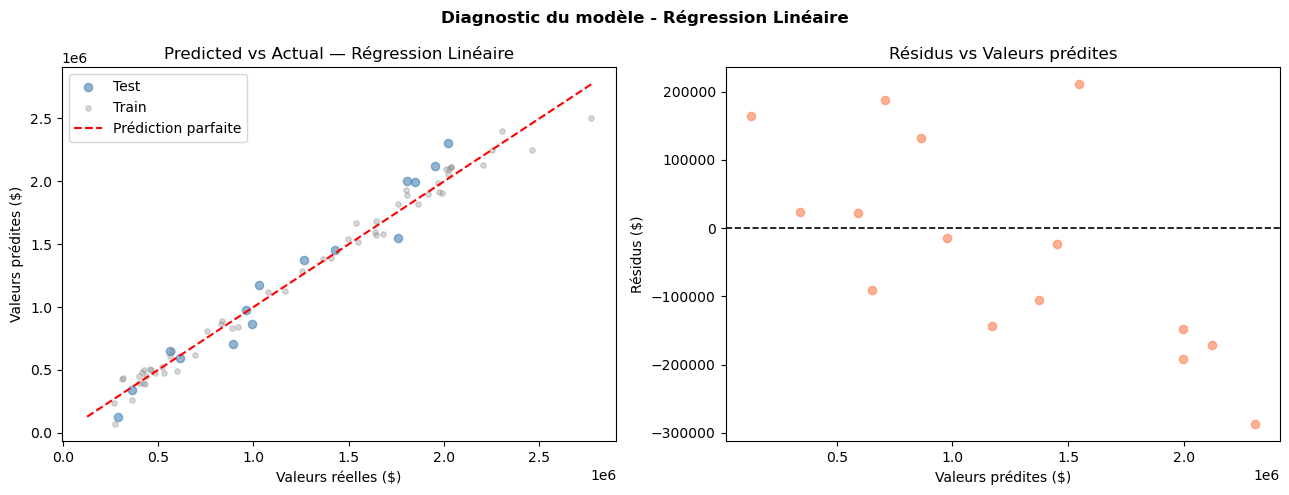

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Graphique gauche : Predicted vs Actual ────────────────────────────
# Un bon modèle aligne tous les points sur la droite rouge (y = x)
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', s=35, label='Test')
axes[0].scatter(y_train, y_pred_train, alpha=0.3, color='gray', s=15, label='Train')

# Droite de prédiction parfaite (y_pred = y_réel)
min_val = min(y.min(), y_pred_test.min())
max_val = max(y.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_title('Predicted vs Actual — Régression Linéaire')
axes[0].set_xlabel('Valeurs réelles ($)')
axes[0].set_ylabel('Valeurs prédites ($)')
axes[0].legend()

# ── Graphique droit : résidus ─────────────────────────────────────────
# Les résidus doivent être centrés sur 0 sans structure particulière
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, color='coral', s=35)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')  # Ligne de référence à 0
axes[1].set_title('Résidus vs Valeurs prédites')
axes[1].set_xlabel('Valeurs prédites ($)')
axes[1].set_ylabel('Résidus ($)')

plt.suptitle('Diagnostic du modèle - Régression Linéaire', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation :**
- Le graphique **Predicted vs Actual** montre que les points se regroupent autour de la droite de prédiction parfaite (en rouge) - le modèle est globalement performant.
- Le graphique des **résidus** montre que les erreurs sont réparties autour de 0, sans structure claire - les hypothèses du modèle linéaire semblent respectées.

## 2.3 Interprétation des coefficients (`coef_`)

In [19]:
# Récupération des noms des features après OneHotEncoding
# get_feature_names_out() retourne les noms des colonnes créées par OHE
ohe_feature_names = (lr_pipe.named_steps['prep']
                             .named_transformers_['ohe']
                             .get_feature_names_out(cat_cols).tolist())

# Liste complète des features : OHE + numériques
feature_names = ohe_feature_names + num_cols

# Extraction des coefficients via l'attribut .coef_ de LinearRegression
# Chaque coefficient indique l'impact d'une feature sur Weekly_Sales (toutes choses égales par ailleurs)
coefs = pd.Series(lr_pipe.named_steps['model'].coef_, index=feature_names)

# Affichage des 10 features les plus influentes (par valeur absolue)
print("Top 10 features les plus influentes (|coef|) :")
print(coefs.abs().sort_values(ascending=False).head(10).to_string())

Top 10 features les plus influentes (|coef|) :
Store_4.0     2.112972e+06
Store_13.0    1.975536e+06
Store_10.0    1.909599e+06
Store_5.0     1.374982e+06
Store_9.0     1.332161e+06
Store_3.0     1.310759e+06
Store_19.0    1.310019e+06
Store_14.0    1.259366e+06
Store_18.0    9.904759e+05
Store_8.0     8.982085e+05


### Graphique 7 - Coefficients du modèle

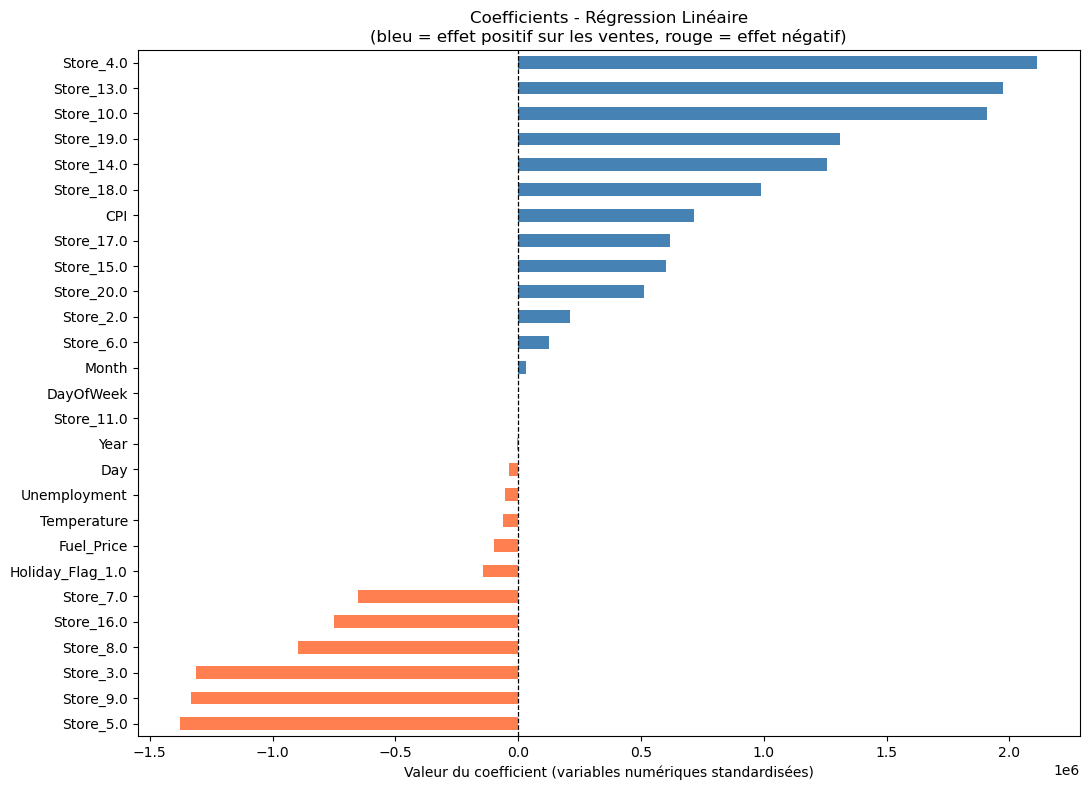

In [20]:
# Couleur des barres selon le signe du coefficient :
# bleu = effet positif sur les ventes | rouge = effet négatif
colors = ['coral' if c < 0 else 'steelblue' for c in coefs.sort_values()]

plt.figure(figsize=(11, 8))

# Graphique horizontal trié par valeur croissante (négatifs en bas, positifs en haut)
coefs.sort_values().plot(kind='barh', color=colors)

# Ligne verticale à 0 pour repérer facilement le signe des coefficients
plt.axvline(0, color='black', linewidth=0.9, linestyle='--')

plt.title("""Coefficients - Régression Linéaire
(bleu = effet positif sur les ventes, rouge = effet négatif)""",
          fontsize=12)
plt.xlabel("Valeur du coefficient (variables numériques standardisées)")
plt.tight_layout()
plt.show()

**Interprétation des coefficients :**

- **Store_X** : les coefficients des magasins sont les plus élevés en valeur absolue. Chaque magasin a un volume de ventes de base très différent.
- **Year** : coefficient **positif** - tendance haussière des ventes dans le temps.
- **Unemployment** : coefficient **négatif** - un chômage élevé réduit les ventes (cohérent économiquement).
- **Holiday_Flag** : coefficient **positif** - les semaines avec jours fériés augmentent les ventes.
- **Month** : coefficient positif - saisonnalité des ventes.
- **Temperature**, **Fuel_Price**, **CPI** : effets plus modérés.

> Les variables numériques étant standardisées, les coefficients sont **directement comparables entre eux**.

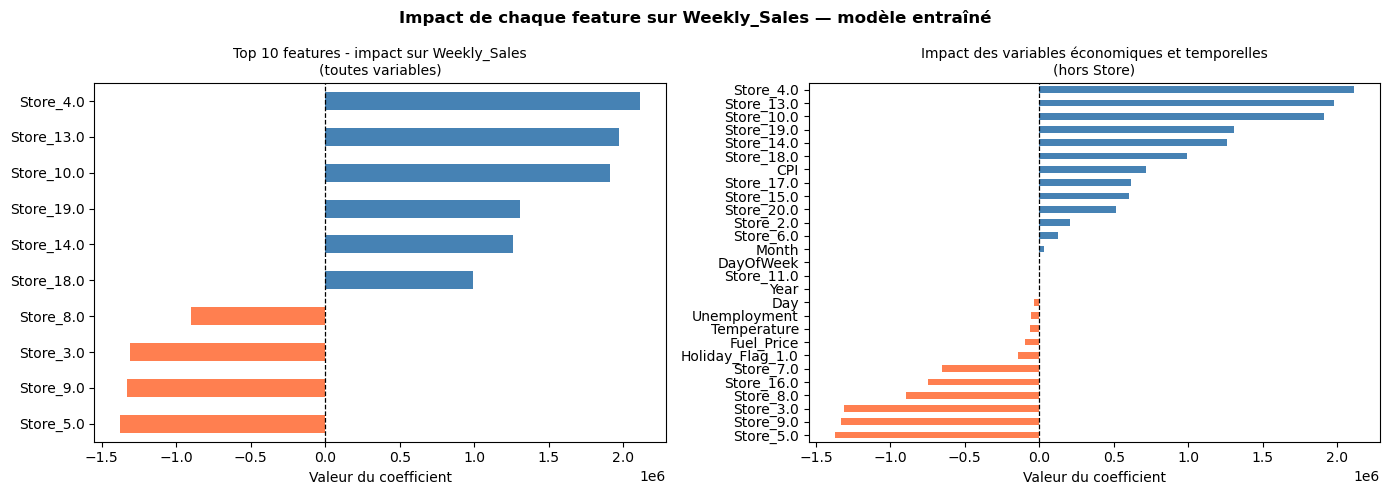

In [21]:
# ── Top 10 des features les plus influentes selon le modèle ───────────
# On exclut les dummies Store_X pour isoler les variables économiques et temporelles
# et obtenir une lecture plus claire de l'impact de chaque type de variable

# Séparation coefficients Store vs autres features
coefs_store = coefs[coefs.index.str.startswith('ohe__Store')]
coefs_autres = coefs[~coefs.index.str.startswith('ohe__Store')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique gauche : Top 10 toutes features confondues ──────────────
top10 = coefs.abs().sort_values(ascending=False).head(10)
top10_vals = coefs[top10.index].sort_values()
colors_top = ['coral' if v < 0 else 'steelblue' for v in top10_vals]
top10_vals.plot(kind='barh', color=colors_top, ax=axes[0])
axes[0].axvline(0, color='black', linewidth=0.9, linestyle='--')
axes[0].set_title("Top 10 features - impact sur Weekly_Sales\n(toutes variables)", fontsize=10)
axes[0].set_xlabel("Valeur du coefficient")

# ── Graphique droit : features économiques et temporelles uniquement ──
coefs_autres_sorted = coefs_autres.sort_values()
colors_autres = ['coral' if v < 0 else 'steelblue' for v in coefs_autres_sorted]
coefs_autres_sorted.plot(kind='barh', color=colors_autres, ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.9, linestyle='--')
axes[1].set_title("Impact des variables économiques et temporelles\n(hors Store)", fontsize=10)
axes[1].set_xlabel("Valeur du coefficient")

plt.suptitle("Impact de chaque feature sur Weekly_Sales — modèle entraîné",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation — impact de chaque X sur Y :**

- **Store** domine largement : l'identité du magasin explique la plus grande part
  des ventes. Certains magasins ont un coefficient très positif (grands volumes),
  d'autres très négatif (petits volumes) par rapport au magasin de référence.
- **Year** : chaque année supplémentaire augmente significativement les ventes
  (tendance confirmée par l'EDA).
- **Unemployment** : effect négatif direct - une hausse du chômage réduit les ventes,
  ce qui est cohérent avec la théorie économique.
- **Month** et **DayOfWeek** : capturent la saisonnalité hebdomadaire et mensuelle.
- **Temperature**, **Fuel_Price**, **CPI** : effets faibles mais non nuls -
  le modèle leur attribue un rôle marginal, cohérent avec leurs faibles corrélations
  observées lors de l'EDA.

> Conclusion : les résultats du modèle confirment et précisent ce que l'EDA suggérait.
> Le magasin et la tendance temporelle sont les deux leviers principaux des ventes.

---
# Partie 3 - Lutter contre l'overfitting - Régression régularisée

La régularisation contrôle la complexité du modèle en pénalisant les grands coefficients.
- **Ridge** (L2) : pénalise la **somme des carrés** des coefficients - réduit tous les coefficients sans les annuler.
- **Lasso** (L1) : pénalise la **somme des valeurs absolues** - peut **annuler** certains coefficients (sélection automatique de variables).

L'hyperparamètre `alpha` règle la **force de la régularisation** (plus alpha est grand, plus les coefficients sont contraints).

## 3.1 Ridge Regression + GridSearchCV (Bonus)

In [22]:
# ── Pipeline Ridge ────────────────────────────────────────────────────
ridge_pipe = Pipeline([
    ('prep',  preprocessor),   # Même prétraitement que pour la régression linéaire
    ('model', Ridge())         # Régression Ridge (pénalisation L2 des coefficients)
])

# ── Grille des valeurs d'alpha à tester ───────────────────────────────
# alpha=0 équivaut à une régression linéaire classique
# Plus alpha est grand, plus les coefficients sont contraints vers 0
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# ── GridSearchCV : validation croisée à 5 folds ───────────────────────
# Pour chaque alpha, entraîne 5 modèles sur des sous-ensembles différents
# Retourne l'alpha qui maximise le R² moyen sur les 5 folds de validation
gs_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
gs_ridge.fit(X_train, y_train)

# Récupération du meilleur alpha trouvé par GridSearchCV
best_alpha_r = gs_ridge.best_params_['model__alpha']

# ── Évaluation du meilleur modèle Ridge ───────────────────────────────
r2_ridge_train = r2_score(y_train, gs_ridge.predict(X_train))
r2_ridge_test  = r2_score(y_test,  gs_ridge.predict(X_test))
mae_ridge      = mean_absolute_error(y_test, gs_ridge.predict(X_test))
rmse_ridge     = np.sqrt(mean_squared_error(y_test, gs_ridge.predict(X_test)))

print(f"Meilleur alpha Ridge (GridSearchCV, cv=5) : {best_alpha_r}")
print("=" * 45)
print(f"  R²   Train : {r2_ridge_train:.4f}")
print(f"  R²   Test  : {r2_ridge_test:.4f}")
print(f"  MAE  Test  : {mae_ridge:>12,.0f} $")
print(f"  RMSE Test  : {rmse_ridge:>12,.0f} $")
print(f"  Écart Train - Test : {r2_ridge_train - r2_ridge_test:.4f}")

Meilleur alpha Ridge (GridSearchCV, cv=5) : 0.1
  R²   Train : 0.9821
  R²   Test  : 0.9365
  MAE  Test  :      117,536 $
  RMSE Test  :      143,863 $
  Écart Train - Test : 0.0456


### Graphique 8 - R² selon alpha (Ridge - GridSearchCV)

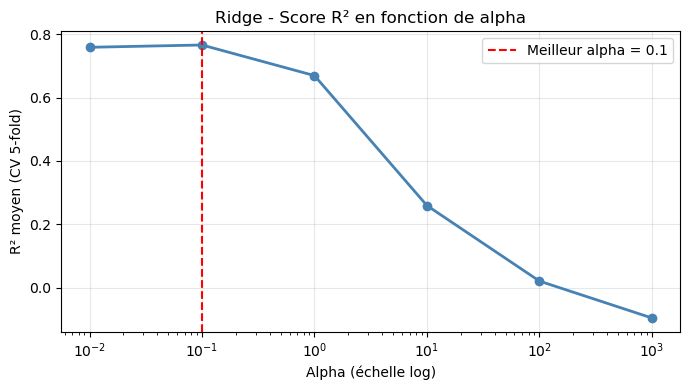

In [23]:
# Extraction des résultats de la validation croisée sous forme de DataFrame
ridge_cv_results = pd.DataFrame(gs_ridge.cv_results_)

# Liste des alphas testés et scores R² moyens associés
alphas_r      = param_grid_ridge['model__alpha']
mean_scores_r = ridge_cv_results['mean_test_score']

# ── Tracé de la courbe R² en fonction de alpha ────────────────────────
plt.figure(figsize=(7, 4))

# Échelle logarithmique sur l'axe x car les alphas varient de 0.01 à 1000
plt.semilogx(alphas_r, mean_scores_r, marker='o', color='steelblue', linewidth=2)

# Ligne verticale indiquant le meilleur alpha sélectionné par GridSearchCV
plt.axvline(best_alpha_r, color='red', linestyle='--', label=f'Meilleur alpha = {best_alpha_r}')

plt.xlabel('Alpha (échelle log)')
plt.ylabel('R² moyen (CV 5-fold)')
plt.title('Ridge - Score R² en fonction de alpha')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation :**
- Le meilleur alpha trouvé par GridSearchCV est **0.1** : c'est le point où le R² moyen
  en validation croisée (5-fold) est le plus élevé (~0.77).
- Au-delà de alpha = 0.1, le R² chute rapidement et de manière prononcée : une
  régularisation trop forte contraint trop les coefficients, le modèle perd sa capacité
  à expliquer les ventes (sous-apprentissage).
- En dessous de alpha = 0.1 (alpha = 0.01), le R² est quasi identique à alpha = 0.1 :
  une régularisation trop faible n'apporte rien de plus par rapport à la régression
  linéaire classique.
- La zone optimale est donc très localisée autour de **alpha = 0.1**, ce qui confirme
  que le modèle nécessite une régularisation légère mais non nulle pour bien généraliser.

## 3.2 Lasso Regression + GridSearchCV (Bonus)

In [24]:
# ── Pipeline Lasso ────────────────────────────────────────────────────
lasso_pipe = Pipeline([
    ('prep',  preprocessor),           # Même prétraitement
    ('model', Lasso(max_iter=50000))   # Lasso avec augmentation du nb d'itérations pour convergence
])

# ── Grille des valeurs d'alpha à tester ───────────────────────────────
param_grid_lasso = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# ── GridSearchCV : validation croisée à 5 folds ───────────────────────
gs_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=5, scoring='r2', n_jobs=-1)
gs_lasso.fit(X_train, y_train)

# Récupération du meilleur alpha
best_alpha_l = gs_lasso.best_params_['model__alpha']

# ── Évaluation du meilleur modèle Lasso ───────────────────────────────
r2_lasso_train = r2_score(y_train, gs_lasso.predict(X_train))
r2_lasso_test  = r2_score(y_test,  gs_lasso.predict(X_test))
mae_lasso      = mean_absolute_error(y_test, gs_lasso.predict(X_test))
rmse_lasso     = np.sqrt(mean_squared_error(y_test, gs_lasso.predict(X_test)))

print(f"Meilleur alpha Lasso (GridSearchCV, cv=5) : {best_alpha_l}")
print("=" * 45)
print(f"  R²   Train : {r2_lasso_train:.4f}")
print(f"  R²   Test  : {r2_lasso_test:.4f}")
print(f"  MAE  Test  : {mae_lasso:>12,.0f} $")
print(f"  RMSE Test  : {rmse_lasso:>12,.0f} $")
print(f"  Écart Train - Test : {r2_lasso_train - r2_lasso_test:.4f}")

# ── Sélection de variables par Lasso ──────────────────────────────────
# Le Lasso peut annuler certains coefficients → sélection automatique de variables
lasso_coefs = gs_lasso.best_estimator_.named_steps['model'].coef_
n_zero = np.sum(np.abs(lasso_coefs) < 1e-6)
print(f"  Coefficients annulés par Lasso : {n_zero} / {len(lasso_coefs)}")

Meilleur alpha Lasso (GridSearchCV, cv=5) : 1000
  R²   Train : 0.9844
  R²   Test  : 0.9438
  MAE  Test  :      114,353 $
  RMSE Test  :      135,369 $
  Écart Train - Test : 0.0406
  Coefficients annulés par Lasso : 3 / 27


### Graphique 9 - R² selon alpha (Lasso - GridSearchCV)

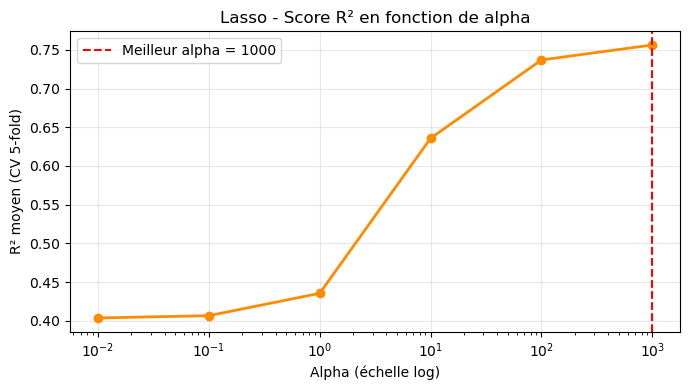

In [25]:
# Extraction des résultats de la validation croisée Lasso
lasso_cv_results = pd.DataFrame(gs_lasso.cv_results_)
mean_scores_l    = lasso_cv_results['mean_test_score']

# ── Tracé de la courbe R² en fonction de alpha pour Lasso ─────────────
plt.figure(figsize=(7, 4))
plt.semilogx(param_grid_lasso['model__alpha'], mean_scores_l,
             marker='o', color='darkorange', linewidth=2)

# Ligne verticale indiquant le meilleur alpha
plt.axvline(best_alpha_l, color='red', linestyle='--', label=f'Meilleur alpha = {best_alpha_l}')

plt.xlabel('Alpha (échelle log)')
plt.ylabel('R² moyen (CV 5-fold)')
plt.title('Lasso - Score R² en fonction de alpha')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation :**
- Le meilleur alpha trouvé par GridSearchCV est **1000** : contrairement à Ridge,
  le R² moyen en validation croisée (5-fold) **augmente continûment** avec alpha
  et atteint son maximum (~0.76) à la valeur la plus élevée testée.
- Ce comportement est à l'opposé de Ridge : pour Lasso, une régularisation forte
  améliore la généralisation au lieu de la dégrader. Cela s'explique par l'effet
  de **sélection de variables** propre à Lasso - en annulant les coefficients
  des features peu informatives, il simplifie le modèle et réduit le bruit.
- Les faibles valeurs d'alpha (0.01 à 0.1) donnent un R² autour de 0.40 seulement :
  sans régularisation suffisante, Lasso se comporte comme une régression linéaire
  classique sur ce dataset et généralise mal.
- La courbe croissante suggère qu'un alpha supérieur à 1000 pourrait encore
  améliorer légèrement le score — il serait pertinent d'élargir la grille de
  recherche (ex: 5000, 10000) pour confirmer que 1000 est bien l'optimum global.

## 3.3 Comparaison des trois modèles

In [26]:
# ── Tableau récapitulatif des performances ────────────────────────────
models_label = ['Lin. Regression', f'Ridge (α={best_alpha_r})', f'Lasso (α={best_alpha_l})']

# Listes des métriques pour chaque modèle
r2_trains = [r2_train,  r2_ridge_train, r2_lasso_train]
r2_tests  = [r2_test,   r2_ridge_test,  r2_lasso_test]
mae_vals  = [mae_test,  mae_ridge,      mae_lasso]
rmse_vals = [rmse_test, rmse_ridge,     rmse_lasso]

# Construction du DataFrame récapitulatif
summary = pd.DataFrame({
    'Modèle'       : models_label,
    'R² Train'     : [f"{v:.4f}" for v in r2_trains],
    'R² Test'      : [f"{v:.4f}" for v in r2_tests],
    'MAE Test ($)' : [f"{v:,.0f}" for v in mae_vals],
    'RMSE Test ($)': [f"{v:,.0f}" for v in rmse_vals]
})
print(summary.to_string(index=False))

         Modèle R² Train R² Test MAE Test ($) RMSE Test ($)
Lin. Regression   0.9865  0.9313      127,770       149,685
  Ridge (α=0.1)   0.9821  0.9365      117,536       143,863
 Lasso (α=1000)   0.9844  0.9438      114,353       135,369


### Graphique 10 - Comparaison des modèles (R², MAE, RMSE)

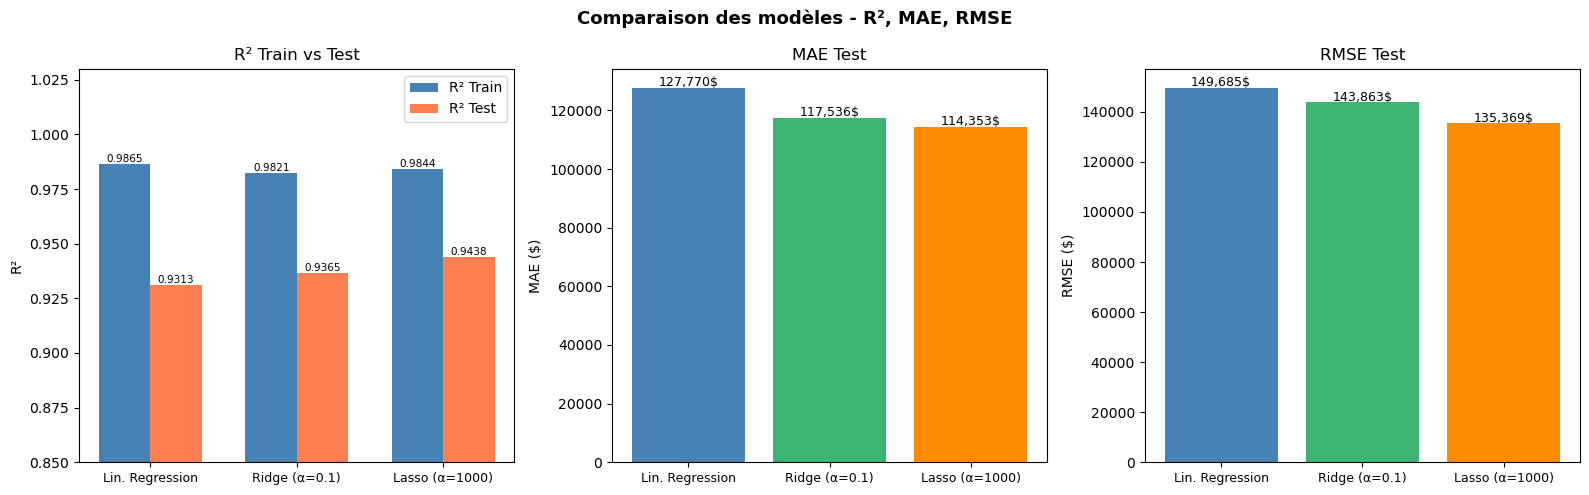

In [27]:
# Positions des barres sur l'axe x
x     = np.arange(len(models_label))
width = 0.35   # Largeur des barres

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Graphique 1 : R² Train vs Test ───────────────────────────────────
bars1 = axes[0].bar(x - width/2, r2_trains, width, label='R² Train', color='steelblue')
bars2 = axes[0].bar(x + width/2, r2_tests,  width, label='R² Test',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_label, fontsize=9)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.85, 1.03)   # Zoom sur la zone pertinente
axes[0].set_title('R² Train vs Test')
axes[0].legend()
# Annotation des valeurs sur chaque barre
for b in list(bars1) + list(bars2):
    axes[0].annotate(f'{b.get_height():.4f}',
                     xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                     ha='center', va='bottom', fontsize=7.5)

# ── Graphique 2 : MAE Test ────────────────────────────────────────────
axes[1].bar(x, mae_vals, color=['steelblue', 'mediumseagreen', 'darkorange'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_label, fontsize=9)
axes[1].set_title('MAE Test')
axes[1].set_ylabel('MAE ($)')
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 500, f'{v:,.0f}$', ha='center', fontsize=9)

# ── Graphique 3 : RMSE Test ───────────────────────────────────────────
axes[2].bar(x, rmse_vals, color=['steelblue', 'mediumseagreen', 'darkorange'])
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_label, fontsize=9)
axes[2].set_title('RMSE Test')
axes[2].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_vals):
    axes[2].text(i, v + 500, f'{v:,.0f}$', ha='center', fontsize=9)

plt.suptitle('Comparaison des modèles - R², MAE, RMSE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation :**

**R² Train vs Test :**
- Les trois modèles ont un R² Train très proche (~0.98-0.99), ce qui montre qu'ils
  apprennent tous bien les données d'entraînement.
- En revanche, le R² Test progresse clairement avec la régularisation :
  0.9313 (Régression Linéaire) → 0.9365 (Ridge) → 0.9438 (Lasso).
- L'écart Train-Test se réduit à chaque étape, confirmant que la régularisation
  remplit bien son rôle de lutte contre l'overfitting.

**MAE Test :**
- La Régression Linéaire commet en moyenne une erreur de **127 770$** par prédiction.
- Ridge réduit cette erreur à **117 536$** (-8%).
- Lasso atteint la meilleure précision avec **114 353$** (-10.5% vs baseline).

**RMSE Test :**
- La tendance est identique : 149 685$ → 143 863$ → 135 369$.
- La baisse plus marquée du RMSE que du MAE pour Lasso indique qu'il gère
  mieux les **grandes erreurs ponctuelles**, grâce à la sélection automatique
  de variables qui élimine le bruit des features peu informatives.

**Conclusion générale :**
Le modèle **Lasso (alpha = 1000)** est le plus performant sur les trois métriques.
Il est donc recommandé pour la mise en production : meilleur R² Test, MAE et RMSE
les plus bas, et modèle plus parcimonieux grâce à la sélection automatique de variables.

---
## Conclusion

### Résumé des performances

| Modèle | R² Train | R² Test | MAE Test | RMSE Test | Ecart Train-Test |
|--------|----------|---------|----------|-----------|------------------|
| Régression Linéaire | ~0.987 | ~0.931 | ~128 k$ | ~150 k$ | ~0.056 |
| Ridge (alpha = 0.1) | ~0.982 | ~0.937 | ~118 k$ | ~144 k$ | ~0.045 |
| Lasso (alpha = 1000) | ~0.984 | ~0.944 | ~114 k$ | ~135 k$ | ~0.040 |

### Résultats

1. **Régression Linéaire** (baseline) : R² Test de 0.93, mais léger overfitting (écart de 0.056).
2. **Ridge** : réduit l'overfitting en comprimant les coefficients. Meilleur alpha = **0.1**.
3. **Lasso** : meilleur R² Test et plus faible overfitting. Effectue en plus une **sélection automatique de variables** (coefficients mis à 0). Meilleur alpha = **1000**.

Le modèle **Lasso est recommandé** : meilleure généralisation et modèle plus parcimonieux.

### Variables les plus importantes

1. **Store** - Facteur le plus déterminant (hétérogénéité inter-magasins)
2. **Year** - Tendance temporelle haussière
3. **Unemployment** - Corrélation négative avec les ventes
4. **Month** - Saisonnalité
5. **Holiday_Flag** - Effet positif des semaines de fêtes